In [1]:
# ─────────────────────────────────────────────
# [C1] 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정 + 실험 데이터 로드
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas scipy statsmodels matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import (proportions_ztest, proportion_effectsize,
                                          confint_proportions_2indep, proportion_confint)
from statsmodels.stats.power import NormalIndPower
plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다. (정답을 심고 확인하는 모든 시뮬레이션에 적용)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정

# 한글 폰트 설정
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    # 리눅스·Colab에서 한글이 □□로 보이면 아래를 먼저 실행하세요.
    # !apt-get -qq install -y fonts-nanum && rm -rf ~/.cache/matplotlib
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# ── 실제 무작위 실험 데이터 (라이브러리 제공) ──
resume = sm.datasets.get_rdataset("ResumeNames", "AER").data     # 이력서 현장실험 4,870건
star   = sm.datasets.get_rdataset("Star", "Ecdat").data          # Project STAR (연속형 결과 RCT)

print("준비 완료!")
print("numpy       :", np.__version__)
print("statsmodels :", sm.__version__)
print()
print(f"resume : {resume.shape}  — 무작위 배정 요인 2개(ethnicity, quality), 결과 = call")
print(f"star   : {star.shape}  — 무작위 배정된 학급 유형 3종, 결과 = 시험 점수")
print()
print("이력서 실험 요약 (그룹별 연락률):")
print(pd.crosstab(resume["ethnicity"], resume["call"], normalize="index").round(4))  # 분할표(교차표) — 두 범주의 조합별 개수를 셈

준비 완료!
numpy       : 2.4.6
statsmodels : 0.14.6

resume : (4870, 27)  — 무작위 배정 요인 2개(ethnicity, quality), 결과 = call
star   : (5748, 8)  — 무작위 배정된 학급 유형 3종, 결과 = 시험 점수

이력서 실험 요약 (그룹별 연락률):
call           no     yes
ethnicity                
afam       0.9355  0.0645
cauc       0.9035  0.0965


In [2]:
# [C2] 잠재결과 시뮬레이션 — '신의 시점'에서 Y(1)과 Y(0)을 모두 본다 (현실엔 불가능)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
n = 2000
Y0 = np.random.normal(100, 20, n)                  # 처치 안 받았을 때의 구매액
true_tau = 8.0                                     # 우리가 '심은' 진짜 효과 (+8)
Y1 = Y0 + true_tau + np.random.normal(0, 5, n)     # 처치 받았을 때 (효과 + 개인차)

sim = pd.DataFrame({"Y0": Y0, "Y1": Y1})
sim["tau_i"] = sim["Y1"] - sim["Y0"]               # 개인 효과 (현실엔 못 봄)
print(sim.head().round(1))
print(f"\n[신의 시점] 진짜 ATE = E[Y(1) - Y(0)] = {sim['tau_i'].mean():.2f}  (우리가 심은 값 ≈ {true_tau})")
print("→ 현실에서는 한 사람당 Y0, Y1 중 하나만 보입니다. 이 표는 시뮬레이션이라 둘 다 보이는 것뿐이에요.")

      Y0     Y1  tau_i
0  109.9  114.6    4.6
1   97.2  104.5    7.3
2  113.0  117.0    4.0
3  130.5  136.9    6.5
4   95.3   93.8   -1.5

[신의 시점] 진짜 ATE = E[Y(1) - Y(0)] = 7.97  (우리가 심은 값 ≈ 8.0)
→ 현실에서는 한 사람당 Y0, Y1 중 하나만 보입니다. 이 표는 시뮬레이션이라 둘 다 보이는 것뿐이에요.


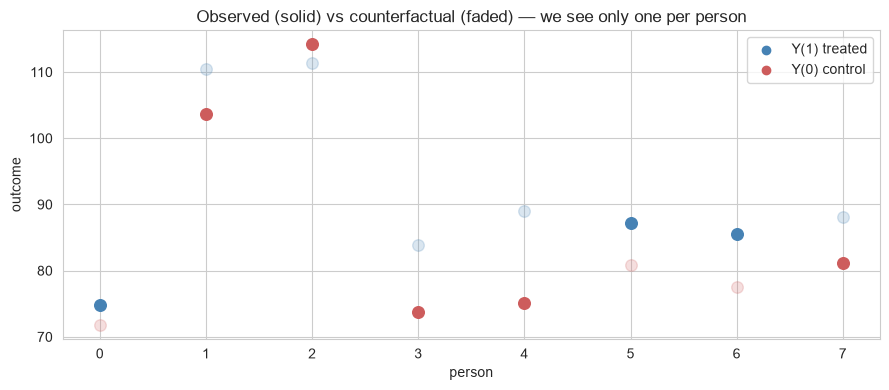

In [3]:
# [C3] 근본 문제를 그림으로 — 관측되는 값과 가려지는 반사실
np.random.seed(1)                                                 # 재현성: 난수를 항상 같게 고정
idx = np.random.choice(n, 8, replace=False)
T_demo = np.random.binomial(1, 0.5, 8)             # 무작위로 처치/대조 배정
fig, ax = plt.subplots(figsize=(9, 4))                            # 그래프 하나를 그릴 도화지 준비
for k, i in enumerate(idx):
    obs = "Y1" if T_demo[k] == 1 else "Y0"
    ax.scatter(k, Y1[i], color="steelblue", s=70, alpha=1 if obs == "Y1" else 0.2)
    ax.scatter(k, Y0[i], color="indianred", s=70, alpha=1 if obs == "Y0" else 0.2)
ax.scatter([], [], color="steelblue", label="Y(1) treated")
ax.scatter([], [], color="indianred", label="Y(0) control")
ax.set_xlabel("person"); ax.set_ylabel("outcome")
ax.set_title("Observed (solid) vs counterfactual (faded) — we see only one per person")
ax.legend(); plt.tight_layout(); plt.show()                       # 그래프 간격 자동 정리 후 출력